## Correlation distance clustering

In [1]:
import numpy as np

DATA_PATH = "student_mental_health_burnout_1M.csv"

# loading data
import pandas as pd
df_1m = pd.read_csv(DATA_PATH)

from pandas.api.types import is_numeric_dtype
numeric_cols = [col for col in df_1m.columns if is_numeric_dtype(df_1m[col])]

num_df_1m = df_1m[numeric_cols].copy()
num_df_1m.iloc[1:100]

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,dropout_risk
1,20,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,0.000000
2,29,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,0.696941
3,27,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,5.380592
4,24,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,0.000000
5,29,3,7.697210,8.460408,68.332246,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,3.869208,3.918780,2.872448,10.000000,1.472916,6.603990,2.731063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,29,3,5.375062,5.338316,80.982024,5.759744,4.271680,3.533563,7.312874,2.980812,3.908400,7.057710,8.622998,9.713833,5.988744,2.950994,5.354529,4.174980
96,18,3,7.958061,9.502525,75.987530,6.433656,3.728825,1.373351,8.517508,2.637354,6.348850,5.133156,4.177367,5.851558,8.886635,2.670052,5.895885,3.365640
97,21,4,8.706658,7.597969,77.639096,7.092993,5.946303,3.397777,5.425566,2.366063,4.963052,4.937139,6.214089,5.486136,8.515191,3.597517,4.359579,1.732625
98,24,4,6.371529,5.788810,71.993119,4.895763,4.286411,1.329208,4.521030,3.077423,6.007947,4.227321,4.804397,3.157183,9.168905,2.384478,6.357009,0.020018


In [ ]:
# standardizing data

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preproc_cluster = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# limit the dataframe dimension to keep the noteboook responsive
num_df_reduced = num_df_1m.iloc[1:10_000]

std_num_df = pd.DataFrame(preproc_cluster.fit_transform(num_df_reduced), columns=num_df_reduced.columns)

In [ ]:
MIN_NEIGHBORS_TO_TEST  = 30
min_neigh_range = [i for i in range(2,MIN_NEIGHBORS_TO_TEST+1)]

from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import pdist, squareform
from kneed import KneeLocator

# dicts for later plotting
k_dists = dict()   
knee_points = dict()
eps_vals = dict()
corr_dist_mat = squareform(pdist(std_num_df, metric="correlation"))

def get_best_eps(min_neigh :int, corr_mat) ->float:
    """
    Automatically find the best eps values (knee of the k-distance plot) for min_neigh value
    """
    # 1st: compute the k-distance
    nbrs = NearestNeighbors(n_neighbors=min_neigh, metric="precomputed")
    nbrs.fit(corr_mat)
    dist, _ = nbrs.kneighbors(corr_mat)   
    k_dist = np.sort(dist[:,-1])

    k_dists[min_neigh] = k_dist # store for plotting
    # 2nd: highlight the 
    kneedle = KneeLocator(range(len(k_dist)), k_dist, 
                      curve='convex', direction='increasing')
    knee_points[min_neigh] = kneedle.knee
    return float(k_dist[kneedle.knee])

from sklearn.cluster import DBSCAN
print("----- starting DBSCAN trend clustering -----")
clusterings_labels = dict()
for min_neigh in min_neigh_range:
    print(f">> computing DBSCAN on min_samples={min_neigh}")
    eps = get_best_eps(min_neigh, corr_dist_mat)
    eps_vals[min_neigh] = eps   # store for plotting
    print(f"   eps value found {eps}")
    dbscan = DBSCAN(eps=eps, min_samples=min_neigh, metric="precomputed")
    clusterings_labels[min_neigh] = dbscan.fit_predict(corr_dist_mat)

----- starting DBSCAN trend clustering -----
>> computing DBSCAN on min_samples=2
   eps value found 0.2525115480282034
>> computing DBSCAN on min_samples=3
   eps value found 0.27534299969152887
>> computing DBSCAN on min_samples=4
   eps value found 0.2896316051342832
>> computing DBSCAN on min_samples=5
   eps value found 0.2924066447001238
>> computing DBSCAN on min_samples=6
   eps value found 0.3163208957929362
>> computing DBSCAN on min_samples=7
   eps value found 0.3346237690726822
>> computing DBSCAN on min_samples=8
   eps value found 0.3188752125524663
>> computing DBSCAN on min_samples=9
   eps value found 0.31828884802408575
>> computing DBSCAN on min_samples=10
   eps value found 0.3237465914328652
>> computing DBSCAN on min_samples=11
   eps value found 0.3267254919321769
>> computing DBSCAN on min_samples=12
   eps value found 0.35869232690430963
>> computing DBSCAN on min_samples=13
   eps value found 0.3523609544999713
>> computing DBSCAN on min_samples=14
   eps val

In [ ]:
for min_neigh in min_neigh_range:
    print(f"Cluster identified with min_pts={min_neigh}-eps={eps_vals[min_neigh]:.4f} : \
          {len(set(clusterings_labels[min_neigh])) - (1 if -1 in clusterings_labels[min_neigh] else 0)}")

Cluster identified with min_pts=2-eps=0.2525 :           6
Cluster identified with min_pts=3-eps=0.2753 :           1
Cluster identified with min_pts=4-eps=0.2896 :           1
Cluster identified with min_pts=5-eps=0.2924 :           1
Cluster identified with min_pts=6-eps=0.3163 :           1
Cluster identified with min_pts=7-eps=0.3346 :           1
Cluster identified with min_pts=8-eps=0.3189 :           1
Cluster identified with min_pts=9-eps=0.3183 :           1
Cluster identified with min_pts=10-eps=0.3237 :           1
Cluster identified with min_pts=11-eps=0.3267 :           1
Cluster identified with min_pts=12-eps=0.3587 :           1
Cluster identified with min_pts=13-eps=0.3524 :           1
Cluster identified with min_pts=14-eps=0.3458 :           1
Cluster identified with min_pts=15-eps=0.3513 :           1
Cluster identified with min_pts=16-eps=0.3434 :           1
Cluster identified with min_pts=17-eps=0.3544 :           1
Cluster identified with min_pts=18-eps=0.3482 : 

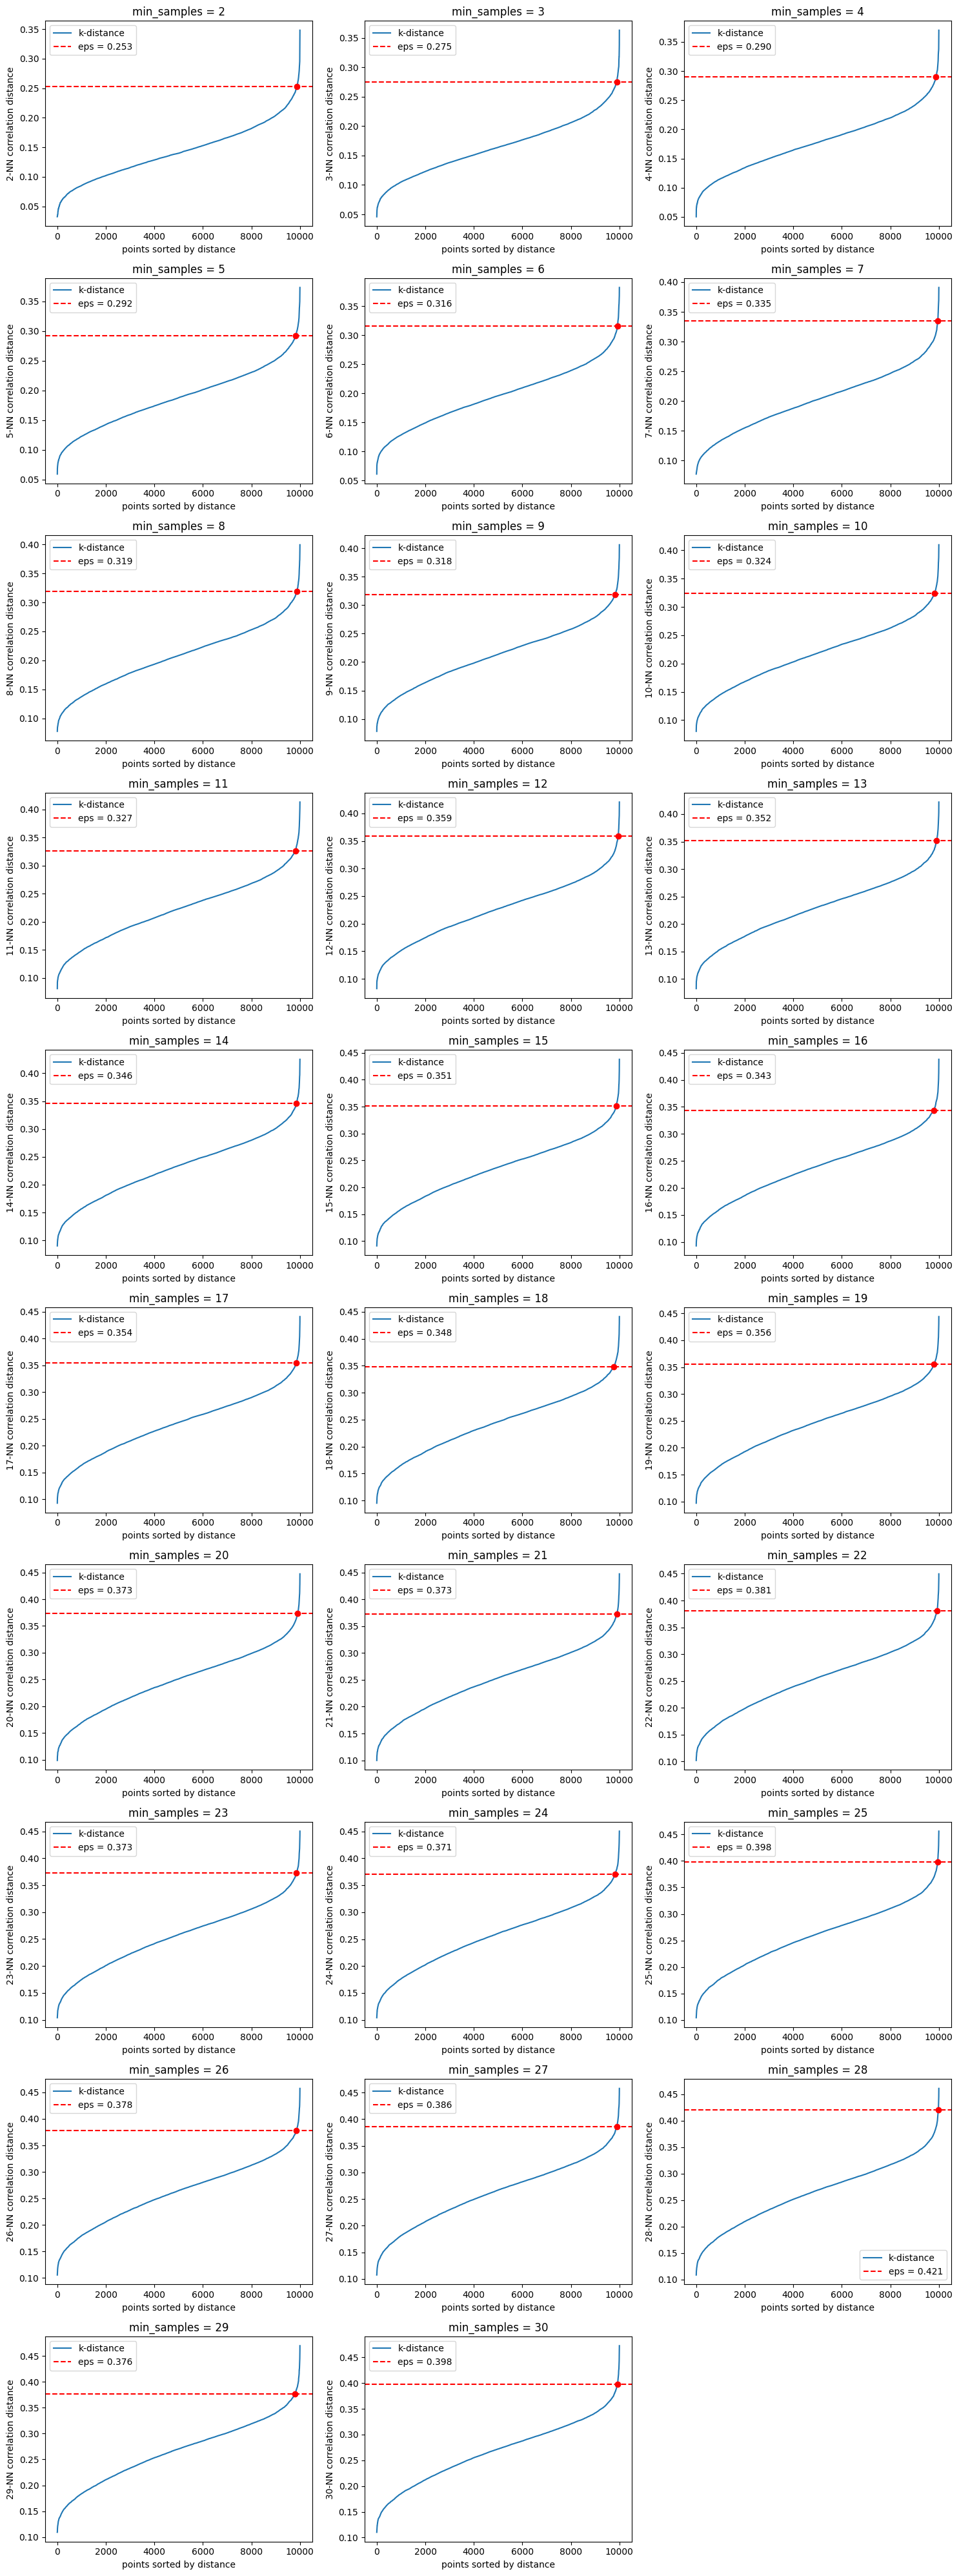

In [ ]:
import matplotlib.pyplot as plt

n_cols = 3
n_rows = int(np.ceil(len(min_neigh_range) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, min_neigh in zip(axes, min_neigh_range):
    k_dist = k_dists[min_neigh]
    knee = knee_points[min_neigh]
    eps = eps_vals[min_neigh]

    ax.plot(k_dist, label="k-distance")
    ax.axhline(eps, color="r", linestyle="--", label=f"eps = {eps:.3f}")
    ax.scatter([knee], [eps], color="r", zorder=5)
    ax.set_title(f"min_samples = {min_neigh}")
    ax.set_xlabel("points sorted by distance")
    ax.set_ylabel(f"{min_neigh}-NN correlation distance")
    ax.legend()

for ax in axes[len(min_neigh_range):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: add clustering indexes